In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# =====================================
# STEP 1 : LOAD LARGE TIME SERIES DATA
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Downloading Electricity Time Series Dataset...")

url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

data = pd.read_csv(url)

print("\nFirst rows:")
display(data.head())

print("\nDataset Info:")
print(data.info())

print("\nShape:", data.shape)
print("\nColumns:", data.columns)

# Convert date column
data["date"] = pd.to_datetime(data["date"])

# Set index
data = data.set_index("date")

print("\nFirst timestamp:", data.index.min())
print("Last timestamp:", data.index.max())

# Save dataset
data.to_csv("electricity_timeseries_large.csv")

print("\nDataset saved as electricity_timeseries_large.csv")


First rows:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB
None

Shape: (17420, 8)

Columns: Index(['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='object')

First timestamp: 2016-07-01 00:00:00
Last timestamp: 2018-06-26 19:00:00

Dataset saved as electricity_timeseries_large.csv


In [34]:
df = data

In [36]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [37]:
df.columns

Index(['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='object')

### Ploting time series

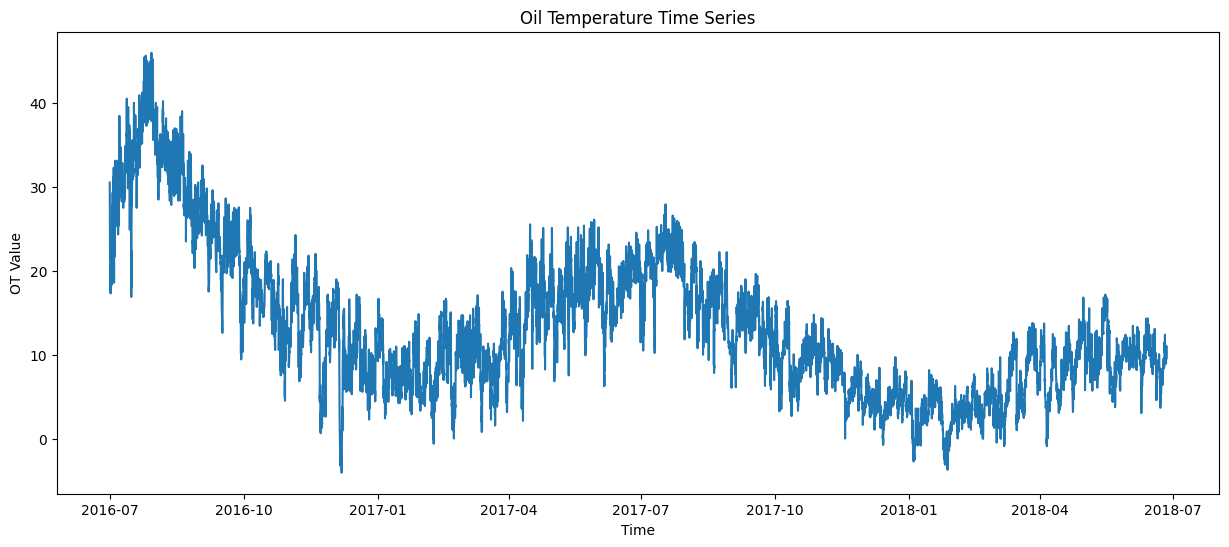

In [38]:
plt.figure(figsize=(15,6))
plt.plot(df["OT"])

plt.title("Oil Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("OT Value")

plt.show()

# Trend

Long Term Movement of the data
eg : OT slowly increasing over months

# Seasonality

Repeating patterns over fixed time interval

eg:Electricity load higher during daytime

# Noise
Random Fluctuations




---





# Rolling Stats (Detect Trend)

### A Rolling Mean calculates the avg over a moving time window

EG: if window = 24
mean(t)= avg of last 24 timestamps

This help us to detect trend



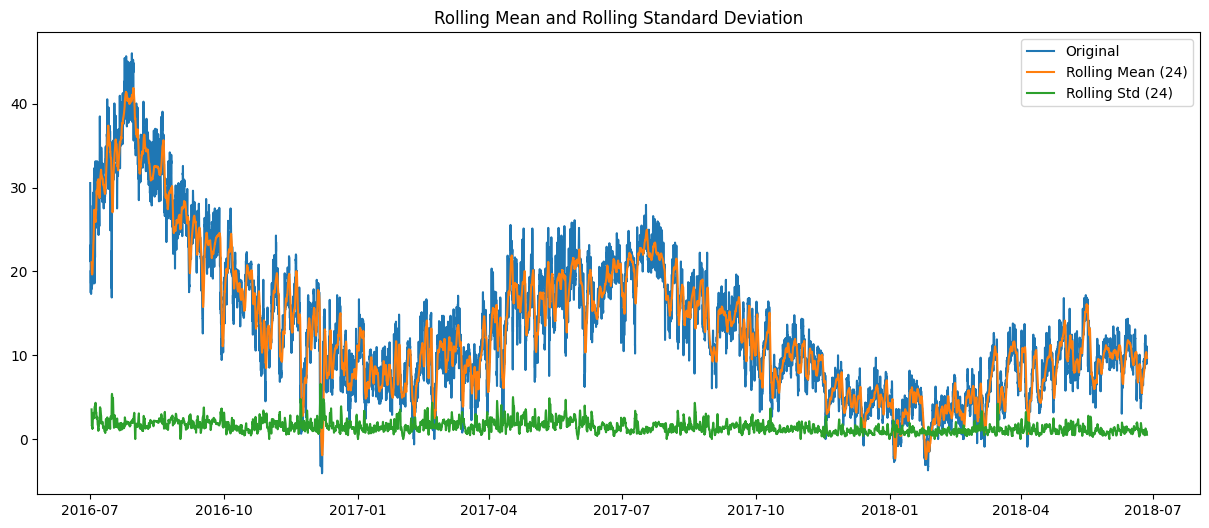

In [39]:
# Rolling stats

rolling_mean = df["OT"].rolling(window=24).mean()
rolling_std = df["OT"].rolling(window=24).std()

plt.figure(figsize=(15,6))

plt.plot(df["OT"],label="Original")
plt.plot(rolling_mean, label="Rolling Mean (24)")
plt.plot(rolling_std, label="Rolling Std (24)")

plt.legend()
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.show()

### In the above plot neither of any is stationary so this data is non stationary

Many Classical Time Series model require Stationary Data

Deep learning models can handle non-stationary data

## Time Series = Trend + Seasonality + Residual

### Decompose the TIme Series

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose


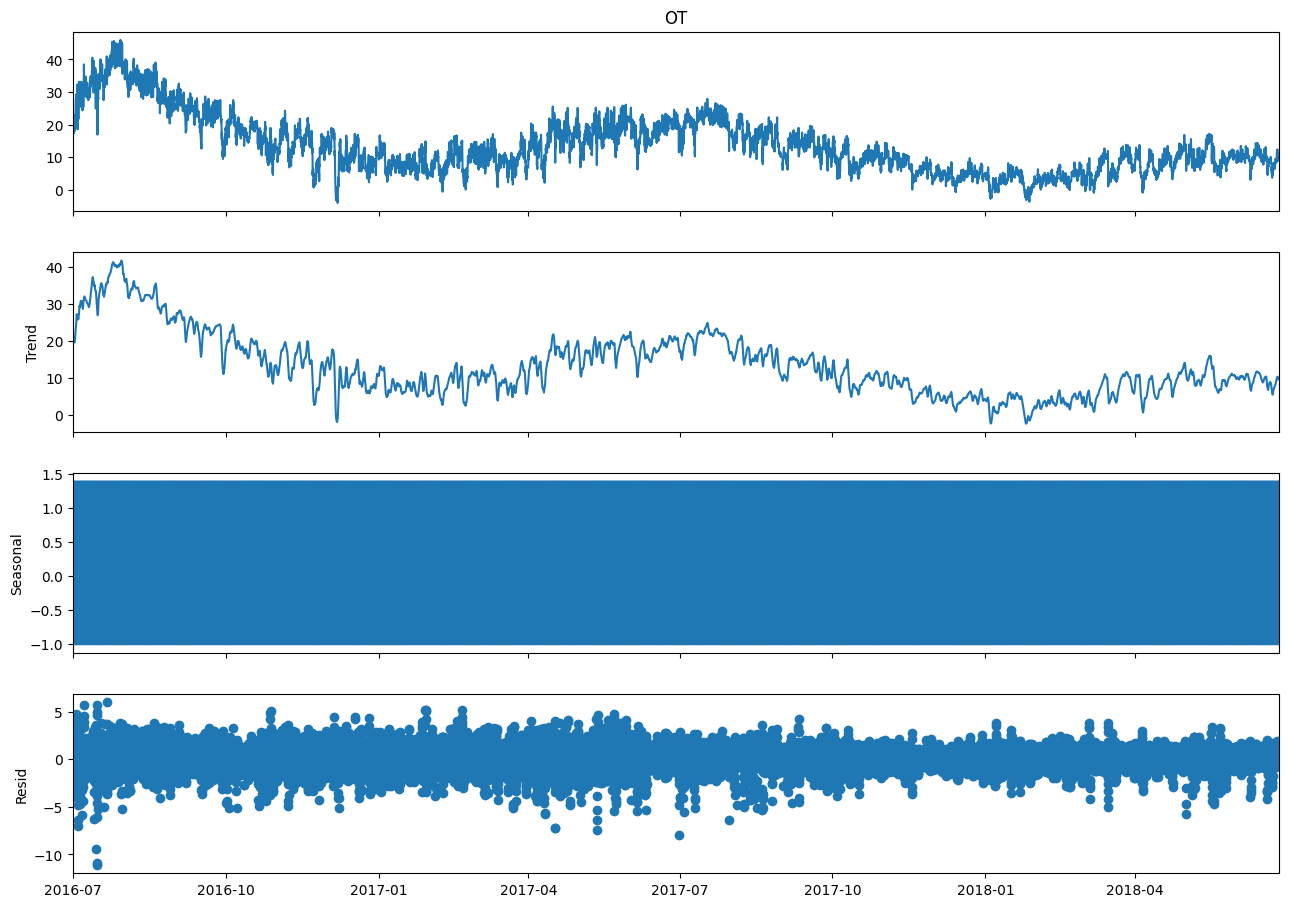

In [43]:
decomposition = seasonal_decompose(df["OT"], model="Additive", period=24)

fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.show()

| Plot     | Meaning            |
| -------- | ------------------ |
| Observed | Original OT series |
| Trend    | Long-term movement |
| Seasonal | Repeating pattern  |
| Residual | Noise              |


Two decomposition models exist:

Additive Model

Used when seasonal variations are constant.

Y = Trend + Seasonality + Residual
Multiplicative Model

Used when seasonal variations increase with time.

Y = Trend × Seasonality × Residual

In most ML preprocessing we start with additive.

This is a sequence over time.

But most ML models (Linear Regression, XGBoost, Neural Nets) expect:

Features → Target

Example:

Feature1	Feature2	Target

They do not understand time ordering automatically.

So we convert time-series into supervised learning format.

In [46]:
## Creating a sliding window dataset

def create_dataset(data,window_size=48):
  X = []
  y = []

  for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
  return np.array(X), np.array(y)

data = df["OT"].values

X, y = create_dataset(data,window_size=48)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (17372, 48)
y Shape: (17372,)


It means:

Feature	Meaning
48	past 48 timestamps
17372	number of training samples

#Original Time Series

t1  t2  t3  t4  t5  t6  t7  t8 ...

Sliding Window (size = 4)

[t1 t2 t3 t4] → t5
[t2 t3 t4 t5] → t6
[t3 t4 t5 t6] → t7
[t4 t5 t6 t7] → t8

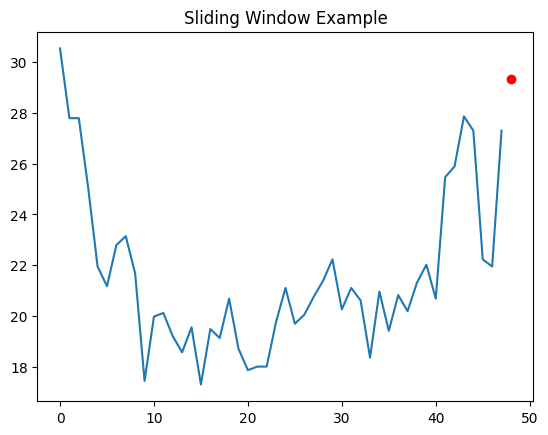

In [48]:
import matplotlib.pyplot as plt

plt.plot(X[0])
plt.scatter(len(X[0]), y[0], color="red")
plt.title("Sliding Window Example")
plt.show()

In [49]:
#Neural Network do not perform well with raw values they work best when data is sca;ed

# LST uses activation function like Tanh, Sigmoid these function
# saturates when values are large so the network stops learning thats why Scaling is required to fixx this


In [50]:
from pandas.tseries.offsets import Minute
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [51]:
#reshape to 2d for scaler
data_scaled = scaler.fit_transform(df[["OT"]])

# Convert back to 1D

data_scaled = data_scaled.flatten()

#recreate sliding window dataset

X,y = create_dataset(data_scaled, window_size=48)

print("Scaled X Shape:", X.shape)
print("Scaled Y Shape:", y.shape)

Scaled X Shape: (17372, 48)
Scaled Y Shape: (17372,)


In [55]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (13897, 48)
Test:  (3475, 48)


In [56]:
# Reshape for LSTM

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (13897, 48, 1)
X_test: (3475, 48, 1)


In [57]:
!pip install tensorflow

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, Adagrad, Adadelta, Nadam


In [65]:
# Build Model

model = Sequential([
    Input(shape=(X_train.shape[1],1)),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

#Train the model

history = model.fit(X_train,y_train,epochs=100,
                    batch_size=32, validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0105 - val_loss: 5.8417e-04
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0020 - val_loss: 4.0556e-04
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0018 - val_loss: 2.9905e-04
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0015 - val_loss: 2.4263e-04
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0013 - val_loss: 2.2528e-04
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0012 - val_loss: 2.6634e-04
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0011 - val_loss: 2.3352e-04
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0010 - val_loss: 2.0636e-04
Epoch 9/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 8.9916e-04 - val_loss: 1.7757e-04
Epoch 10/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 8.1937e-04 - val_loss: 2.5851e-04
Epoch 11/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 7.71

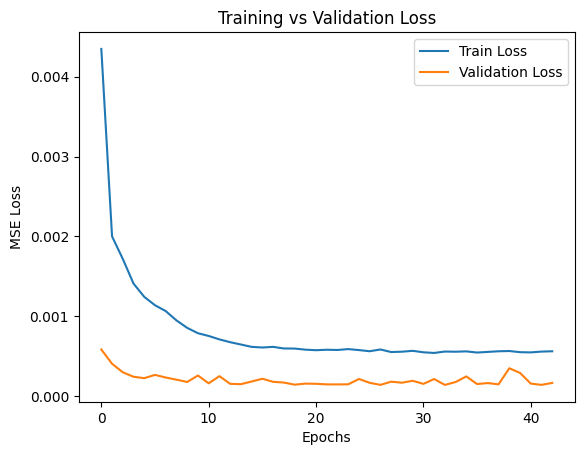

In [68]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [69]:
y_pred = model.predict(X_test)

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [70]:
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))

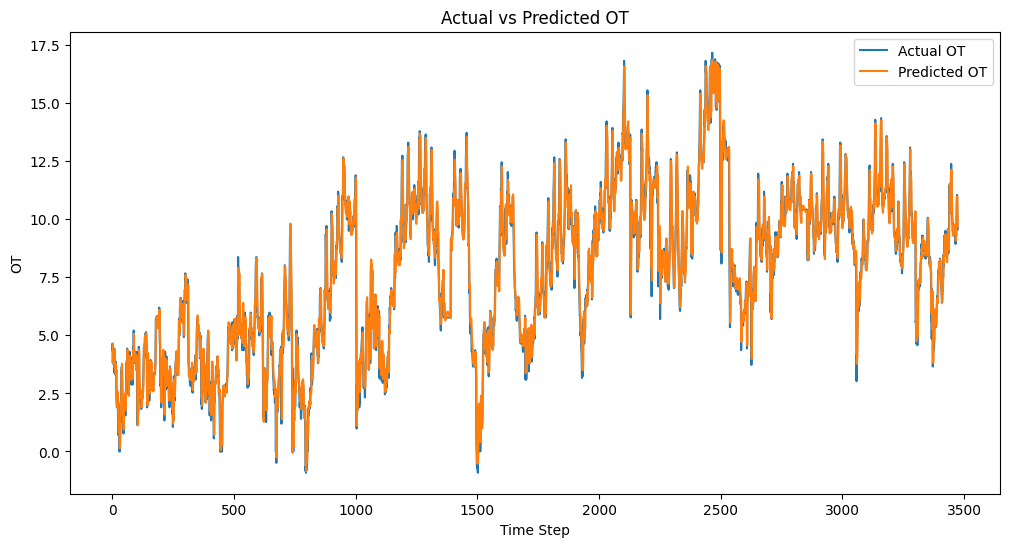

In [71]:
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual OT')
plt.plot(y_pred_rescaled, label='Predicted OT')
plt.title("Actual vs Predicted OT")
plt.xlabel("Time Step")
plt.ylabel("OT")
plt.legend()

In [72]:
print("Train start:", df.index[:X_train.shape[0]][0])
print("Train end:", df.index[:X_train.shape[0]][-1])
print("Test start:", df.index[X_train.shape[0]:X_train.shape[0]+X_test.shape[0]][0])
print("Test end:", df.index[X_train.shape[0]:X_train.shape[0]+X_test.shape[0]][-1])

Train start: 2016-07-01 00:00:00
Train end: 2018-01-31 00:00:00
Test start: 2018-01-31 01:00:00
Test end: 2018-06-24 19:00:00


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# y_pred_rescaled and y_test_rescaled should be in original scale
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mask = y_test_rescaled != 0
mape = np.mean(np.abs((y_test_rescaled[mask] - y_pred_rescaled[mask]) / y_test_rescaled[mask])) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE (ignoring zeros): {mape:.2f}%")

MAE  : 0.4419
RMSE : 0.6457
MAPE (ignoring zeros): 8.88%


In [78]:
# -----------------------------
# FUTURE PREDICTION PREPARATION
# -----------------------------

import numpy as np

# Set the window size (number of past timesteps to use for predicting next OT)
future_window = 48  # same as used for training

# Initialize lists
X_future = []
y_future = []

# Loop over the DataFrame to create sliding windows
# We use .iloc for proper Pandas indexing
for i in range(len(df) - future_window):
    # X: past 'future_window' values of OT (or any feature)
    X_future.append(df.iloc[i:i+future_window, 6].values)  # column index 6 = OT
    # y: next value of OT
    y_future.append(df.iloc[i + future_window, 6])

# Convert lists to NumPy arrays
X_future = np.array(X_future).reshape(-1, future_window, 1)  # LSTM expects 3D input
y_future = np.array(y_future)

# Print shapes to verify
print("X_future shape:", X_future.shape)
print("y_future shape:", y_future.shape)

X_future shape: (17372, 48, 1)
y_future shape: (17372,)


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
Future Predictions Metrics:
MAE  : 7.1404
RMSE : 10.2394
MAPE : 42.26%


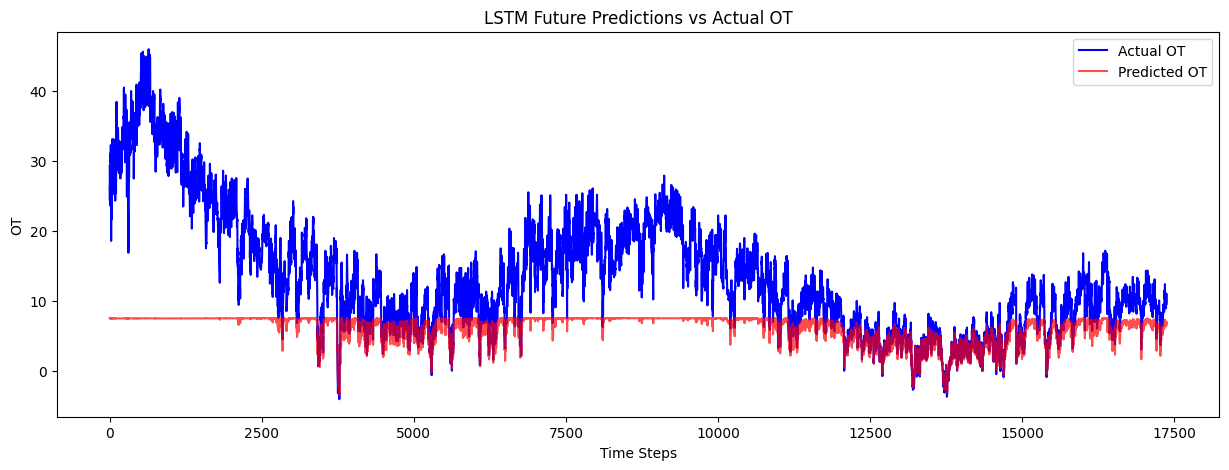

In [79]:
# -----------------------------
# FUTURE PREDICTION + VISUALIZATION
# -----------------------------

import matplotlib.pyplot as plt

# Predict future OT values using the trained LSTM
y_future_pred = model.predict(X_future, batch_size=64)

# If you scaled your target during training, rescale it back
# (Assuming you used a scaler like MinMaxScaler)
if 'scaler_y' in globals():
    y_future_pred_rescaled = scaler_y.inverse_transform(y_future_pred)
    y_future_rescaled = scaler_y.inverse_transform(y_future.reshape(-1, 1))
else:
    y_future_pred_rescaled = y_future_pred
    y_future_rescaled = y_future

# Compute metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_future_rescaled, y_future_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_future_rescaled, y_future_pred_rescaled))
# MAPE with zero handling
mask = y_future_rescaled.flatten() != 0
mape = np.mean(np.abs((y_future_rescaled.flatten()[mask] - y_future_pred_rescaled.flatten()[mask]) / y_future_rescaled.flatten()[mask])) * 100

print(f"Future Predictions Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# Plot Actual vs Predicted OT
plt.figure(figsize=(15,5))
plt.plot(y_future_rescaled, label="Actual OT", color='blue')
plt.plot(y_future_pred_rescaled, label="Predicted OT", color='red', alpha=0.7)
plt.title("LSTM Future Predictions vs Actual OT")
plt.xlabel("Time Steps")
plt.ylabel("OT")
plt.legend()
plt.show()

Why Your LSTM Collapsed

During training/testing, the model always saw real past OT values (X_test) when predicting the next step.

In real future forecasting, you don’t have future OT values — you feed the model’s own predictions recursively.

Any small prediction error compounds quickly, causing the model to “regress” toward the mean.

Think of it like throwing a ball toward a moving target: if your first throw is slightly off, every subsequent throw compounds the error — eventually you’re way off.

| Approach                              | Description                                                                                                         |
| ------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Seq2Seq LSTM/GRU**                  | Encoder-decoder that learns full sequence mapping. The encoder summarizes past, decoder predicts multi-step future. |
| **Temporal Fusion Transformer (TFT)** | State-of-the-art for multivariate, long-horizon forecasting with attention on relevant features/time steps.         |
| **N-BEATS / N-HiTS**                  | Deep decomposition networks — separate trend & seasonality explicitly, better long-term predictions.                |
| **Informer / Autoformer**             | Transformers optimized for very long sequences.                                                                     |
| **Feature engineering**               | Add seasonality, trend decomposition (STL, Fourier features) to help model learn dynamics.                          |


In [81]:
# Seq2Seq LSTM for Multi-Step Forecasting

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [84]:
#parameters

past_steps = 48
future_steps = 24
n_features = 1

#Reshape X to 3d ( samples, timesteps, features)
X_seq = X.reshape((X.shape[0], X.shape[1], n_features))

#prepare y_seq for multi-step
y_seq = []
for i in range(len(y) - future_steps + 1):
    y_seq.append(y[i:i+future_steps])
y_seq = np.array(y_seq).reshape(-1, future_steps, 1)

# Adjust X_seq to match y_seq length
X_seq = X_seq[:y_seq.shape[0], :, :]

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)


X_seq: (17349, 48, 1)
y_seq: (17349, 24, 1)


In [85]:
# -----------------------------
# Build Seq2Seq LSTM
# -----------------------------
encoder_inputs = Input(shape=(past_steps, n_features))
encoder_lstm = LSTM(64, activation='relu', return_sequences=False)(encoder_inputs)
encoder_output = Dense(32, activation='relu')(encoder_lstm)

# Repeat for decoder
decoder_inputs = RepeatVector(future_steps)(encoder_output)
decoder_lstm = LSTM(64, activation='relu', return_sequences=True)(decoder_inputs)
decoder_outputs = TimeDistributed(Dense(1))(decoder_lstm)

model = Model(encoder_inputs, decoder_outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,873 (171.38 KB)

 Trainable params: 43,873 (171.38 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_seq, y_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

# -----------------------------
# Predict Multi-Step
# -----------------------------
y_pred_seq = model.predict(X_seq)


Epoch 1/50
217/217 - 17s - 79ms/step - loss: 0.0133 - val_loss: 0.0016
Epoch 2/50
217/217 - 21s - 96ms/step - loss: 0.0031 - val_loss: 0.0015
Epoch 3/50
217/217 - 15s - 67ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 4/50
217/217 - 16s - 74ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 5/50
217/217 - 10s - 46ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 6/50
217/217 - 11s - 51ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 7/50
217/217 - 21s - 96ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 8/50
217/217 - 19s - 89ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 9/50
217/217 - 11s - 50ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 10/50
217/217 - 12s - 55ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 11/50
217/217 - 12s - 55ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 12/50
217/217 - 11s - 51ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 13/50
217/217 - 11s - 52ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 14/50
217/217 - 19s - 87ms/step - loss: 0.0026 - val_loss: 0.0013
E

In [87]:
# Compute Metrics (example for first 24 steps)
mae = mean_absolute_error(y_seq.reshape(-1), y_pred_seq.reshape(-1))
rmse = np.sqrt(mean_squared_error(y_seq.reshape(-1), y_pred_seq.reshape(-1)))
mape = np.mean(np.abs((y_seq.reshape(-1) - y_pred_seq.reshape(-1)) / (y_seq.reshape(-1)+1e-8))) * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 0.0323
RMSE: 0.0447
MAPE: 41375.92%


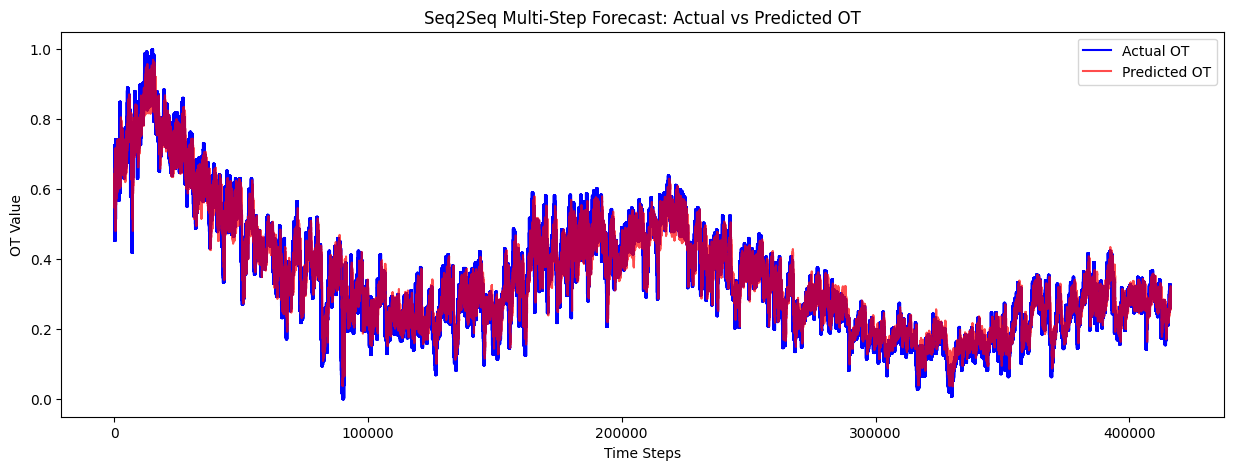

In [88]:
import matplotlib.pyplot as plt

# y_seq -> actual future OT values
# y_pred_seq -> predicted OT values from your Seq2Seq model

plt.figure(figsize=(15,5))
plt.plot(y_seq.reshape(-1), label='Actual OT', color='blue')
plt.plot(y_pred_seq.reshape(-1), label='Predicted OT', color='red', alpha=0.7)
plt.title("Seq2Seq Multi-Step Forecast: Actual vs Predicted OT")
plt.xlabel("Time Steps")
plt.ylabel("OT Value")
plt.legend()
plt.show()

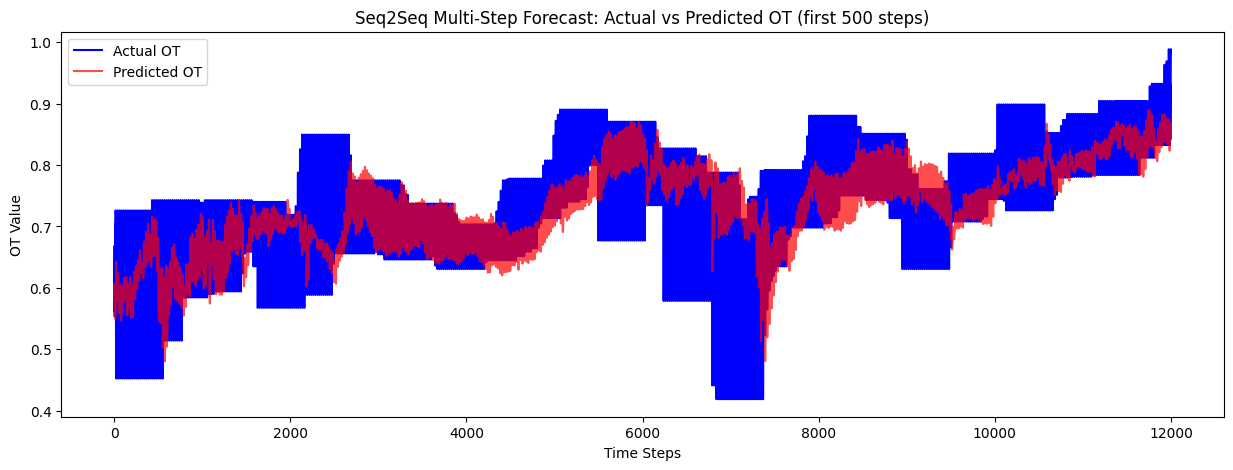

In [91]:
import matplotlib.pyplot as plt

# Flatten to 1D for plotting
y_actual_flat = y_seq[:500].reshape(-1)
y_pred_flat   = y_pred_seq[:500].reshape(-1)

plt.figure(figsize=(15,5))
plt.plot(y_actual_flat, label='Actual OT', color='blue')
plt.plot(y_pred_flat, label='Predicted OT', color='red', alpha=0.7)
plt.title("Seq2Seq Multi-Step Forecast: Actual vs Predicted OT (first 500 steps)")
plt.xlabel("Time Steps")
plt.ylabel("OT Value")
plt.legend()
plt.show()